**HEART DISEASE PREDICTION SYSTEM USING MACHINE LEARNING AND DATA SCIENCE**

**1.PROBLEM STATEMENT**

1.To develop a system that predicts heart disease using patient health data.

2.To apply data science techniques for analyzing medical datasets.

3.To build a machine learning model for accurate prediction.

4.To assist in early diagnosis and better healthcare decision-making.

**2.IMPORT LIBRARIES**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

**3.LOAD DATA**

In [35]:
df = pd.read_csv("heart.csv")

**4.BASIC ANALYSIS**

In [36]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       15 non-null     int64
 1   sex       15 non-null     int64
 2   cp        15 non-null     int64
 3   trestbps  15 non-null     int64
 4   chol      15 non-null     int64
 5   thalach   15 non-null     int64
 6   target    15 non-null     int64
dtypes: int64(7)
memory usage: 972.0 bytes
None
             age        sex         cp    trestbps        chol     thalach  \
count  15.000000  15.000000  15.000000   15.000000   15.000000   15.000000   
mean   54.666667   0.733333   0.266667  129.466667  249.266667  142.533333   
std     9.589180   0.457738   0.593617   15.878407   56.368008   22.465423   
min    34.000000   0.000000   0.000000  100.000000  149.000000  106.000000   
25%    51.500000   0.500000   0.000000  119.000000  206.500000  125.000000   
50%    54.000000   1.000000   0.000000  128.00000

**5. VISUALIZATION**

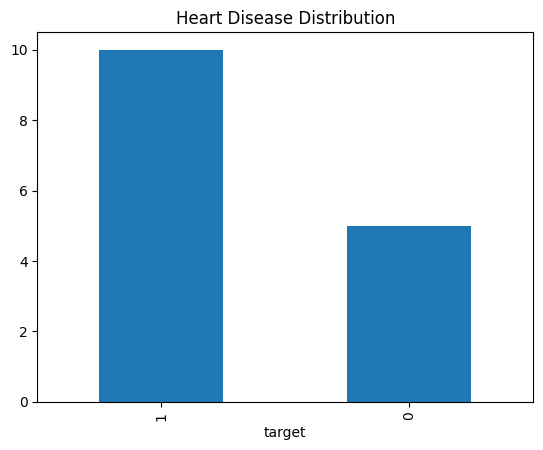

In [37]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

**6.CORRELATION HEATMAP**

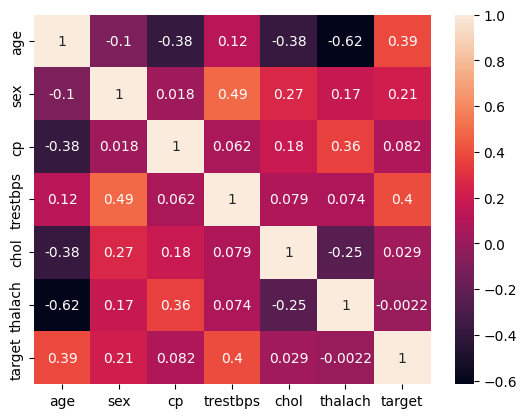

In [38]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)
plt.show()

**7.SPLIT DATA**

In [39]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**8.MODELS**

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

**9.TRAIN & EVALUATE**

In [41]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.0
Decision Tree Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.3333333333333333


**10.MODEL**

In [42]:
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]



Best Model: Decision Tree


**11.SAMPLE PREDICTION**

In [43]:
sample = np.array([[52,1,0,125,212,168]])
prediction = best_model.predict(sample)

print("\nPrediction:")
if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")


Prediction:
Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
